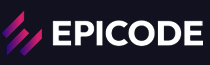

# **Analisi Diffusione COVID-19**
#### Il committente richiede di avere un report su casi e vaccinazioni in diverse aree del mondo; a tal fine, richiede di utilizzare i dati, raccolti e curati da Our World in Data, all'indirizzo https://github.com/owid/covid-19-data/tree/master/public/data dove si trovano le informazioni relative.
#### In particolare, il dataset si può scaricare dalla piattaforma o dall’indirizzo https://raw.githubusercontent.com/owid/covid-19-data/refs/heads/master/public/data/owid-covid-data.csv

## Document Setup

In [30]:
# Import delle librerie necessarie
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display

# Import del csv "owid-data"
url = "https://raw.githubusercontent.com/owid/covid-19-data/refs/heads/master/public/data/owid-covid-data.csv"

# Definizione del dataframe
df = pd.read_csv(url)

## 1. Si richiede di verificare le dimensioni del dataset e i relativi metadati.

### Dimensioni del dataset

In [2]:
print(f"Righe: {df.shape[0]}, Colonne: {df.shape[1]}")

Righe: 429435, Colonne: 67


### Struttura del dataset

In [3]:
df.head(1)

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN


### Dati interessati all'analisi

Osservando la struttura del dataset possiamo notare che non tutte le colonne sono necessarie ai fini della nostra analisi. Andiamo dunque ad evidenziare le colonne sulle quali opereremo:

In [24]:
df[["location", "continent","total_cases","new_cases","icu_patients","hosp_patients"]].iloc[0]

location         Afghanistan
continent               Asia
total_cases              0.0
new_cases                0.0
icu_patients             NaN
hosp_patients            NaN
Name: 0, dtype: object

***location & continent:*** i dati relativi alle colonne "_location_" e "_continent_" si presentano come puntuali per quanto riguarda i nomi dei Paesi ed i Continenti interessati (_es.:"Asia" o "Afghanistan"_) ed aggregati per gli insiemi "_world_", "_International_", "_OWID_EUR_" e "_OWID_WRL_".

***total_cases:*** È il numero cumulativo di casi confermati dal primo giorno della pandemia fino a alla data in questione. Il valore cresce quotidianamente e non diminuisce.

***new_cases:*** È il numero di nuovi casi registrati in un solo giorno. Viene considerato come un indicatore di incidenza giornaliera.

***hosp_patients:*** Indica il numero di pazienti ricoverati in ospedale in quel determinato giorno.

***icu_patients:*** È il dato relativo al numero di pazienti ricoverati in terapia intensiva in quel determinato giorno.

## 2. Si chiede di trovare, per ogni continente:

### (a) - il numero di casi fin dall'inizio della pandemia.

In [25]:
# Visualizziamo l'ultimo record per ogni location, in modo da avere il dato più recente di total_cases
ultimi_dati = (
    df[["location", "continent", "total_cases"]]
    .dropna(subset=["total_cases"])
    .groupby("location")
    .tail(1)
    .sort_values("location")
    .reset_index(drop=True)
)

# Visualizziamo la tabella evidenziando in rosso i valori NaN e formattando i decimali
ultimi_dati.style\
    .highlight_null(color="red")\
    .format({"total_cases": "{:,.0f}"})

,location,continent,total_cases
0,Afghanistan,Asia,"235,214"
1,Africa,nan,"13,145,380"
2,Albania,Europe,"335,047"
3,Algeria,Africa,"272,139"
4,American Samoa,Oceania,"8,359"
5,Andorra,Europe,"48,015"
6,Angola,Africa,"107,481"
7,Anguilla,North America,"3,904"
8,Antigua and Barbuda,North America,"9,106"
9,Argentina,South America,"10,101,218"


 Come si evince dalla tabella, ci sono record relativi ad insiemi diversi (Africa, High-income countries, World ecc.) Il prossimo passo sarà quello di isolare questi valori in modo da escluderli dalla lista dei Paesi.


In [6]:
# Isoliamo tutte le righe che presentano dati NaN nella colonna "continent", poiché non sono Paesi.
valori_nan = ultimi_dati[
    ultimi_dati[["location", "continent", "total_cases"]].isna().any(axis=1)
].reset_index(drop=True)

# Stampiamo a video un conteggio delle righe con valore NaN
print(f"Righe con almeno un NaN: {len(valori_nan)}")

# Visualizziamo la tabella formattando i decimali
valori_nan.style.format({"total_cases": "{:,.0f}"})

Righe con almeno un NaN: 12


,location,continent,total_cases
0,Africa,nan,"13,145,380"
1,Asia,nan,"301,499,099"
2,Europe,nan,"252,916,868"
3,European Union (27),nan,"185,822,587"
4,High-income countries,nan,"429,044,049"
5,Low-income countries,nan,"1,944,334"
6,Lower-middle-income countries,nan,"91,954,400"
7,North America,nan,"124,492,666"
8,Oceania,nan,"15,003,352"
9,South America,nan,"68,809,418"


In [7]:
# Filtriamo i dati relativi ai Continenti tramite una lista.
continenti = ["Africa", "Asia", "Europe", "North America", "South America", "Oceania"]

# Creiamo una stringa per racchiudere tutti i dati relativi ai soli Continenti.
totale_casi_continenti = (
    valori_nan[valori_nan["location"].isin(continenti)][["location", "total_cases"]]
    .reset_index(drop=True)
)

# Visualizziamo la tabella definitiva evidenziando in rosso i dati più rilevanti e rimuovendo i decimali.
totale_casi_continenti.style\
    .background_gradient(subset=["total_cases"], cmap="Reds")\
    .format({"total_cases": "{:,.0f}"})

,location,total_cases
0,Africa,"13,145,380"
1,Asia,"301,499,099"
2,Europe,"252,916,868"
3,North America,"124,492,666"
4,Oceania,"15,003,352"
5,South America,"68,809,418"


In [8]:
# Filtriamo i dati relativi al record World per ricavare il totale dei casi e poi poterlo confrontare con quello dei Paesi.
totale_casi_mondo = (
    valori_nan[valori_nan["location"] == "World"][["location", "total_cases"]]
    .reset_index(drop=True)
)

totale_casi_mondo

,location,total_cases
0,World,775866783.0


In [17]:
# Filtriamo i dati NaN, escludendoli in una stringa di soli Paesi.
totale_casi_paesi = (
    ultimi_dati[ultimi_dati["continent"].notna()]
    .reset_index(drop=True)
)

# Visualizziamo la tabella definitiva evidenziando in rosso i dati più rilevanti e rimuovendo i decimali.
totale_casi_paesi.style\
    .background_gradient(subset=["total_cases"], cmap="Reds")\
    .format({"total_cases": "{:,.0f}"})

,location,continent,total_cases
0,Afghanistan,Asia,"235,214"
1,Albania,Europe,"335,047"
2,Algeria,Africa,"272,139"
3,American Samoa,Oceania,"8,359"
4,Andorra,Europe,"48,015"
5,Angola,Africa,"107,481"
6,Anguilla,North America,"3,904"
7,Antigua and Barbuda,North America,"9,106"
8,Argentina,South America,"10,101,218"
9,Armenia,Asia,"452,273"


#### Il totale dei casi di Covid-19 dall'inizio della pandemia (registrati nel database) è:

In [10]:
# Verifichiamo che la somma della colonna "total_cases" di "totale_casi_paesi" corrisponda a totale_casi_mondo, se si, visualizziamo il numero e diamo la risposta al quesito dell'esame.
if totale_casi_mondo["total_cases"].values[0] == totale_casi_paesi["total_cases"].sum():
    display(
        totale_casi_mondo[["total_cases"]].style
        .set_properties(subset=["total_cases"], **{"background-color": "red", "color": "white"})
        .format({"total_cases": "{:,.0f}"})
        .hide(axis="columns")
        .hide(axis="index")
    )
else:
    print(False)

"775,866,783"


### (b) - la percentuale rispetto al totale mondiale del numero di casi.

Scrivi il nome del paese in inglese:  italy


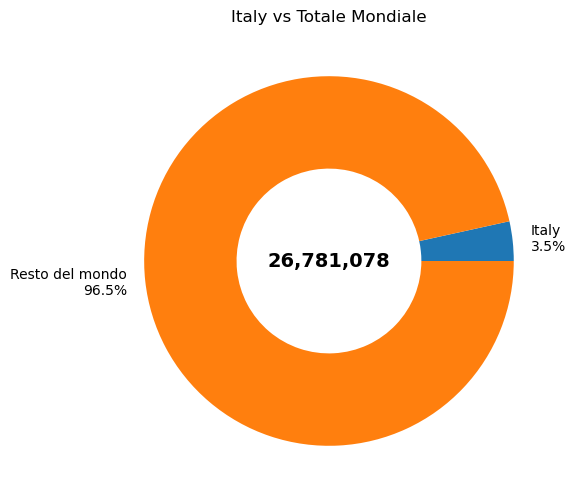

In [11]:
# Creiamo un box input per chiedere all'utente di inserire il nome di un Paese
box = input("Scrivi il nome del paese in inglese: ")

print ()
print ()
print ()

# Creiamo una stringa per permettere di cercare il Paese senza specificare maiuscole o minuscole
ricerca = totale_casi_paesi[totale_casi_paesi["location"].str.lower() == box.strip().lower()]

# Scriviamo un blocco condizionale che ci restituisca il record del Paese cercato e calcoli la percentuale rispetto al resto del mondo
if ricerca.empty:
    print("Paese non trovato.")
else:
    percentuale = (ricerca["total_cases"].values[0] / totale_casi_mondo["total_cases"].values[0]) * 100

# Creiamo un grafico che mostri la relazione percentuale del record cercato rispetto al resto del mondo
    valori = [ricerca["total_cases"].values[0], totale_casi_mondo["total_cases"].values[0] - ricerca["total_cases"].values[0]]
    etichette = [
        f"{ricerca['location'].values[0]}\n{percentuale:.1f}%",
        f"Resto del mondo\n{100 - percentuale:.1f}%"
    ]

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.pie(valori, labels=etichette, wedgeprops=dict(width=0.5))
    ax.text(0, 0, f"{ricerca['total_cases'].values[0]:,.0f}", ha="center", va="center",
        fontsize=14, fontweight="bold")
    ax.set_title(f"{ricerca['location'].values[0]} vs Totale Mondiale")
    plt.show()

## 3. Selezionare i dati relativi all'Italia nel 2022 e, poiché i nuovi casi vengono registrati settimanalmente, filtrare via i giorni che non hanno misurazioni; quindi mostrare con dei grafici adeguati:

### (a) - l'evoluzione dei casi totali dall'inizio alla fine dell'anno

In questa sezione analizziamo l'andamento cumulativo dei casi COVID-19 
in Italia nel corso del 2022. I dati vengono filtrati per escludere 
i giorni privi di misurazione, poiché le rilevazioni sono settimanali.

In [27]:
# Convertiamo la colonna "date" in formato datetime
df["date"] = pd.to_datetime(df["date"])

# Selezioniamo i dati dell'Italia nel 2022 filtrando i giorni senza misurazioni
italia_2022 = df[
    (df["location"] == "Italy") &
    (df["date"].dt.year == 2022) &
    (df["new_cases"].notna()) &
    (df["new_cases"] > 0)
].reset_index(drop=True)

Adesso realizziamo un grafico che mostri chiaramente l'evoluzione dei casi totali in Italia durante il 2022 tramite un grafico a linee di Plotly Express, al quale aggiungiamo il comando: _fig.update_layout(hovermode="x unified")_. Quando si passerà il mouse sopra l'area di disegno, comparirà una linea verticale ancorata all'asse X (data corrispondente) che mostrerà in un unico riquadro di testo i valori esatti di tutte le linee intersecate in quel momento.



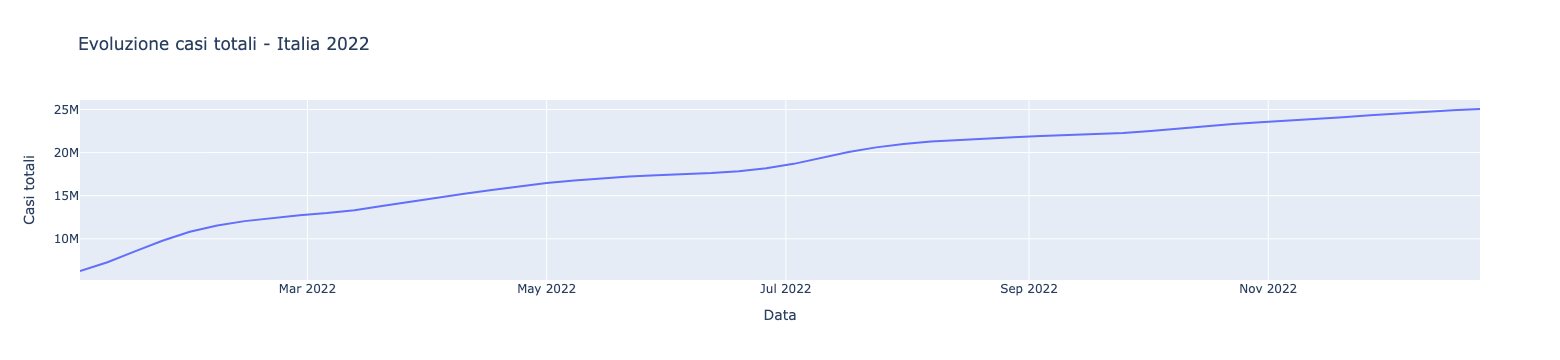

In [29]:
# Grafico a linee interattivo
fig = px.line(
    italia_2022,
    x="date",
    y="total_cases",
    title="Evoluzione casi totali - Italia 2022",
    labels={"date": "Data", "total_cases": "Casi totali"},
)

fig.update_layout(
    xaxis_title="Data",
    yaxis_title="Casi totali",
    hovermode="x unified"
)

fig.show()

### (b) - Il numero di nuovi casi rispetto alla data

In questa sezione è possibile cercare una data specifica e visualizzare il numero di nuovi casi registrati in Italia in quella settimana, evidenziato rispetto all'andamento dell'intero anno.

Sono state sviluppate due versioni:
- La prima, più basilare, è stata realizzata con un _input_ di ricerca, ma poiché i record vengono aggiunti settimanalmente risulta più limitante perché l'utente deve inseire un giorno specifico. (N.B.: il primo record dell'anno è *il 2022-01-02*).

- La seconda è la versione più "User friendly", realizzata con _ipywidgets_ e _Display_ per poter presentare un menu dropdown ed un bottone, che una volta azionati ci restituiscono il report di nuovi casi ed il grafico creato con _plotly_ per permettere una visualizzazione dettagliata e la possibilità di leggere le etichette dei record con la funzione _hovermode_.

In [18]:
# Versione base con input

# Creiamo un box input
data_input = input("Scrivi una data (formato YYYY-MM-DD): ")
data_cercata = pd.to_datetime(data_input.strip())
risultato = italia_2022[italia_2022["date"] == data_cercata]

if risultato.empty:
    print(f"❌ Nessun dato trovato per '{data_input}'.")
    print(f"💡 Date disponibili: {italia_2022['date'].dt.strftime('%Y-%m-%d').tolist()}")
else:
    nuovi_casi = risultato["new_cases"].values[0]
    print(f"\n📅 Data:        {data_input}")
    print(f"🦠 Nuovi casi:  {nuovi_casi:,.0f}")

Scrivi una data (formato YYYY-MM-DD):  2022-01-2



📅 Data:        2022-01-2
🦠 Nuovi casi:  644,604


In [32]:
# Versione con ipywidgets e Display

# Creiamo il dropdown con le date disponibili
date_disponibili = italia_2022["date"].dt.strftime("%Y-%m-%d").tolist()

dropdown = widgets.Dropdown(
    options=date_disponibili,
    description="📅 Data:",
    layout=widgets.Layout(width="250px"),
)

bottone = widgets.Button(description="Cerca")
output = widgets.Output()


def on_click(b):
    output.clear_output()
    with output:
        data_cercata = pd.to_datetime(dropdown.value)
        risultato = italia_2022[italia_2022["date"] == data_cercata]
        nuovi_casi = risultato["new_cases"].values[0]

        print(f"\n📅 Data:        {dropdown.value}")
        print(f"🦠 Nuovi casi:  {nuovi_casi:,.0f}")

        italia_2022["colore"] = italia_2022["date"].apply(
            lambda d: "Data cercata" if d == data_cercata else "Altri giorni"
        )

        fig = px.bar(
            italia_2022,
            x="date",
            y="new_cases",
            color="colore",
            color_discrete_map={"Data cercata": "orange", "Altri giorni": "steelblue"},
            title=f"Nuovi casi settimanali - Italia 2022 | evidenziato: {dropdown.value}",
            labels={"date": "Data", "new_cases": "Nuovi casi", "colore": ""},
        )
        fig.update_layout(hovermode="x unified")
        fig.show()


bottone.on_click(on_click)
display(dropdown, bottone, output)

Dropdown(description='📅 Data:', layout=Layout(width='250px'), options=('2022-01-02', '2022-01-09', '2022-01-16…

Button(description='Cerca', style=ButtonStyle())

Output()

## 4. Riguardo le nazioni di Italia, Germania e Francia:

### (a) - Mostrare in un boxplot la differenza tra queste nazioni riguardo il numero di pazienti in terapia intensiva (Intensive Care Unit, ICU, considerare quindi la colonna icu_patients) da maggio 2022 (incluso) ad aprile 2023 (incluso).

In questa sezione confrontiamo la distribuzione dei pazienti ricoverati in terapia intensiva (ICU) tra Italia, Germania e Francia nel periodo compreso tra maggio 2022 e aprile 2023. Il boxplot permette di visualizzare mediana, variabilità e outlier per ciascuna nazione.

In [33]:
# Filtriamo i dati per le 3 nazioni nel periodo richiesto
nazioni = ["Italy", "Germany", "France"]

icu_data = df[
    (df["location"].isin(nazioni))
    & (df["date"] >= "2022-05-01")
    & (df["date"] <= "2023-04-30")
    & (df["icu_patients"].notna())
][["location", "date", "icu_patients"]].reset_index(drop=True)

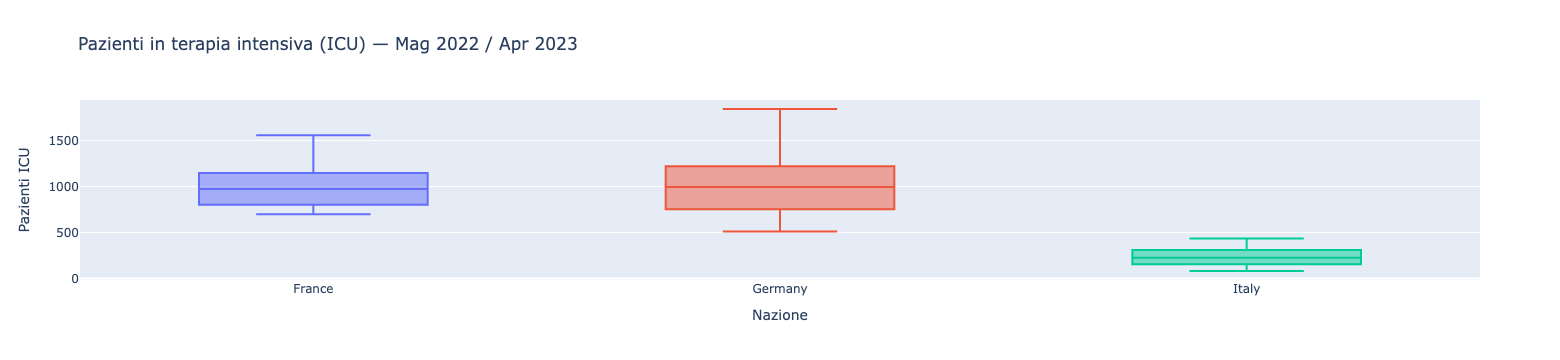

In [38]:
# Grafico Boxplot "icu_patients" per Francia Germania e Italia
fig = px.box(
    icu_data,
    x="location",
    y="icu_patients",
    color="location",
    title="Pazienti in terapia intensiva (ICU) — Mag 2022 / Apr 2023",
    labels={"location": "Nazione", "icu_patients": "Pazienti ICU"},
)

fig.update_layout(showlegend=False)
fig.show()

### (b) - scrivere un breve commento (una o due righe) riguardo che conclusioni possiamo trarre osservando il grafico risultante

Dal boxplot emerge che la Germania presenta il numero mediano di pazienti ICU più elevato nel periodo analizzato, con una distribuzione più ampia che indica maggiore variabilità. Italia e Francia mostrano valori mediani più contenuti e simili tra loro, con la Francia che presenta alcuni outlier nella parte alta.

## 5. Riguardo le nazioni di Italia, Germania, Francia e Spagna in tutto il 2021:

### (a) - Mostrare, in maniera grafica oppure numerica, la somma dei pazienti ospitalizzati per ognuna (colonna hosp_patients)

Nazione  Totale ospedalizzati
 France             6008717.0
  Italy             4419950.0
  Spain             2411706.0


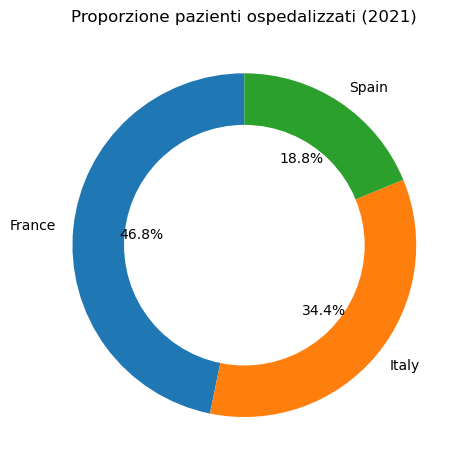

In [61]:
df["date"] = pd.to_datetime(df["date"])

# Filtriamo i dati per le 4 nazioni nel 2021
nazioni = ["Italy", "Germany", "France", "Spain"]

hosp_2021 = df[
    (df["location"].isin(nazioni)) &
    (df["date"].dt.year == 2021) &
    (df["hosp_patients"].notna())
][["location", "hosp_patients"]]

# Somma dei pazienti ospedalizzati per nazione
somma_hosp = hosp_2021.groupby("location")["hosp_patients"].sum().reset_index()
somma_hosp.columns = ["Nazione", "Totale ospedalizzati"]
somma_hosp = somma_hosp.sort_values("Totale ospedalizzati", ascending=False)

print(somma_hosp.to_string(index=False))

# Grafico a torta
fig, ax = plt.subplots()

# Mostriamo nel grafico la percentuale, partendo da ore 12.
ax.pie(
    somma_hosp["Totale ospedalizzati"], 
    labels=somma_hosp["Nazione"],
    autopct='%1.1f%%',       # Mostra la percentuale con un decimale
    startangle=90,           # Ruota il primo spicchio a ore 12
)

# Aggiungiamo un cerchio bianco al centro per creare l'effetto "Donut"
centro_bianco = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centro_bianco)

ax.set_title("Proporzione pazienti ospedalizzati (2021)")
plt.tight_layout()
plt.show()

### (b) - Se ci sono dati nulli, con un breve commento scrivere se può essere possibile gestirli tramite sostituzione o meno

In [59]:
# Verifichiamo i valori nulli per hosp_patients nel 2021 per le 4 nazioni
nazioni = ["Italy", "Germany", "France", "Spain"]

hosp_2021_check = df[
    (df["location"].isin(nazioni)) &
    (df["date"].dt.year == 2021)
][["location", "date", "hosp_patients"]]

nulli_per_nazione = hosp_2021_check.groupby("location")["hosp_patients"].apply(
    lambda x: x.isna().sum()
).reset_index()
nulli_per_nazione.columns = ["Nazione", "Valori nulli"]

print(nulli_per_nazione.to_string(index=False))

Nazione  Valori nulli
 France             0
Germany           365
  Italy             0
  Spain             0


Come si evince dalla verifica, Francia, Italia e Spagna non presentano valori nulli nel 2021. La Germania, invece, registra 365 valori nulli, il che equivale alla totale assenza di dati sui pazienti ospedalizzati per l'intero anno. A fronte di una mancanza totale del dato, non è possibile applicare alcuna tecnica di sostituzione o imputazione matematica, rendendo di fatto impossibile analizzare questa metrica per la Germania.